In [2]:
import os
import numpy as np
import pandas as pd
dataset_enhanced = pd.read_csv('data/oropharynx_evaluation_dataset_clin_trial_updated_2025.csv', header = [0,1,2])

## Let's set it up

In [3]:
import lymph
import emcee

graph_dict = {
    ('tumor', 'T')  : ['II', 'III'], 
    ('lnl'  , 'II') : ['III'], 
    ('lnl'  , 'III'): [], 
}
model = lymph.models.Unilateral.binary(graph_dict=graph_dict)
model.set_modality("max_llh", spec = 1, sens = 1)
model.load_patient_data(dataset_enhanced, side = "ipsi")


/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/unilateral.py:542: DataWarning: Modality enbloc_dissected does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/unilateral.py:542: DataWarning: Modality enbloc_positive does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(


In [4]:
from scipy.special import factorial

def binom_pmf(k: np.ndarray, n: int, p: float):
    """Binomial PMF"""
    if p > 1. or p < 0.:
        # This value error is important to enable seamless sampling!
        raise ValueError("Binomial prob must be btw. 0 and 1")
    q = (1. - p)
    binom_coeff = factorial(n) / (factorial(k) * factorial(n - k))
    return binom_coeff * p**k * q**(n - k)

def late_binomial(support: np.ndarray, p: float = 0.5) -> np.ndarray:
    """Parametrized binomial distribution."""
    return binom_pmf(k=support, n=support[-1], p=p)

model.set_distribution("early", binom_pmf(np.arange(11), 10, 0.3))
model.set_distribution("late", late_binomial)

In [5]:
backend = emcee.backends.HDFBackend(filename = "II_II")

In [14]:
from multiprocess import Pool
# plus one dimension for the late T-stage's time parameter
ndim = len(model.get_params())

# number of concurrent walkers that sample the space
nwalkers = 10 * ndim
# define the log-likelihood
def log_prob_fn(theta):    
    return model.likelihood(given_params=theta, log=True)

max_steps = 6000
backend.reset(nwalkers, ndim)

# initialize the sampler with some random samples
starting_points = np.random.uniform(size=(nwalkers,ndim))

# use Pool() from multiprocessing for parallelisation
with Pool() as pool:
    original_sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_prob_fn,
        pool=pool, backend=backend, parameter_names = [
                   'TtoII_spread', 'TtoIII_spread', 'IItoIII_spread', 'late_p']
    )
    original_sampler.run_mcmc(starting_points,nsteps=max_steps, progress=True)


100%|██████████| 6000/6000 [05:56<00:00, 16.85it/s]


burn-in: 88
thin: 18
flat chain shape: (13120, 4)
(6000, 40, 4)


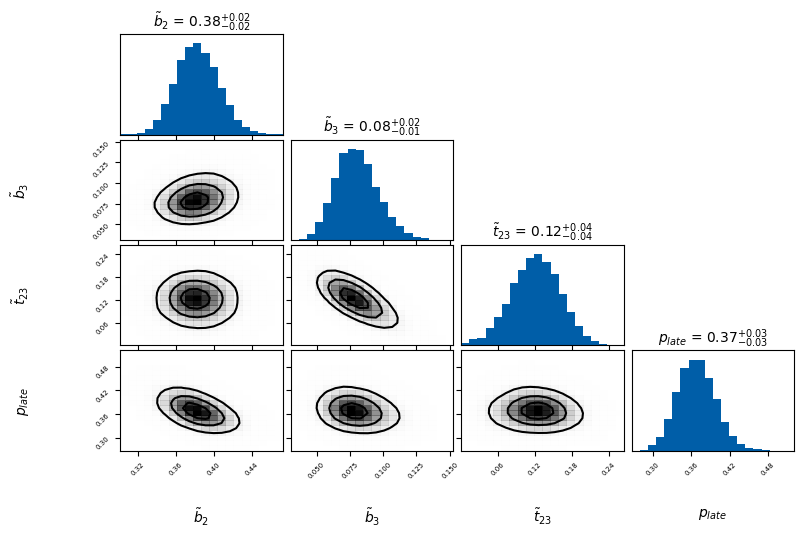

In [ ]:
tau = backend.get_autocorr_time()
burnin = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))
samples = backend.get_chain(discard=burnin, flat=True, thin=thin)
print("burn-in: {0}".format(burnin))
print("thin: {0}".format(thin))
print("flat chain shape: {0}".format(samples.shape))
print(backend.get_chain().shape)


import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from cycler import cycler
import corner

# USZ colors
usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'

# colormaps
white_to_blue  = LinearSegmentedColormap.from_list("white_to_blue", 
                                                   ["#ffffff", usz_blue], 
                                                   N=256)
white_to_green = LinearSegmentedColormap.from_list("white_to_green", 
                                                   ["#ffffff", usz_green], 
                                                   N=256)
green_to_red   = LinearSegmentedColormap.from_list("green_to_red", 
                                                   [usz_green, usz_red], 
                                                   N=256)

h = usz_gray.lstrip('#')
gray_rgba = tuple(int(h[i:i+2], 16) / 255. for i in (0, 2, 4)) + (1.0,)
tmp = LinearSegmentedColormap.from_list("tmp", [usz_green, usz_red], N=128)
tmp = tmp(np.linspace(0., 1., 128))
tmp = np.vstack([np.array([gray_rgba]*128), tmp])
halfGray_halfGreenToRed = ListedColormap(tmp)


def set_size(width="single", unit="cm", ratio="golden"):
    if width == "single":
        width = 10
    elif width == "full":
        width = 20
    else:
        try:
            width = width
        except:
            width = 10
            
    if unit == "cm":
        width = width / 2.54
        
    if ratio == "golden":
        ratio = 1.618
    else:
        ratio = ratio
    
    try:
        height = width / ratio
    except:
        height = width / 1.618
        
    return (width, height)



labels = [r"$\tilde{b}_2$", r"$\tilde{b}_3$", r"$\tilde{t}_{23}$", r"$p_{late}$"]

fig = plt.figure(figsize=set_size(width="full", ratio='golden'))
# using the corner plot package

corner.corner(samples, labels=labels, smooth=True, fig=fig, 
              hist_kwargs={'histtype': 'stepfilled', 'color': usz_blue}, 
              **{'plot_datapoints': False, 'no_fill_contours': True, 
                 "density_cmap": white_to_blue.reversed(), 
                 "contour_kwargs": {"colors": "k"}, 
                 "levels": np.array([0.2, 0.5, 0.8])}, 
              show_titles=True, title_kwargs={"fontsize": 10},labelpad =0.25);

axes = fig.get_axes()
for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=5)

## Run the analysis

In [9]:
import sys
sys.path.append('Trial-calculator')
from sparing_scripts import change_base, sample_from_flattened, risk_sampled, levels_to_spare, ci_single
samples_reduced = sample_from_flattened(samples, num_samples = 200)
model.set_modality('treatment_diagnose', spec = 1, sens = 0.81)

In [10]:
diagnose = {'treatment_diagnose':{
        "II": 0,
        "III": 0,

    }}
sampled_risks, mean_risks = risk_sampled(samples = samples_reduced, model = model, t_stage = 'early', given_diagnoses= diagnose)     
spared_lnls, total_risk, ranked_combined, treated_lnls, treated_lnls_names, treated_array, sampled_total_risks = levels_to_spare(0.10, model, mean_risks, sampled_risks, ci = False)
print(treated_lnls_names)
print(total_risk*100)
print(spared_lnls)
ci_single(sampled_total_risks)*100

['II']
5.100379731802519
[('III', np.float64(0.05100379731802519))]


array([4.01054469, 6.39715261])

In [15]:
from sparing_scripts import change_base

def produce_combinations_list(array):
    combinations_list = []
    for entry in array:
        combination = []
        for index, cells in enumerate(entry):
            if index == 0:
                combination.append('early') if cells == 0 else combination.append('late')
            else:
                combination.append(False) if cells == 0 else combination.append(True)
        combination = tuple(combination)
        combinations_list.append(combination)
    return(combinations_list)

combination_array = np.zeros((2**3,3))
for i in range(2**3):
    combination_array[i] = [
        int(digit) for digit in change_base(i, 2, length=3)
    ]

all_combinations = produce_combinations_list(combination_array)

In [ ]:
from sparing_scripts import analysis_treated_lnls_combinations_unilateral
treated_lnls_no_risk, treated_lnls_all, treatment_array, top3_spared, total_risks, sampled_risks_array, lnls_ranked, cis = analysis_treated_lnls_combinations_unilateral(combinations = all_combinations, model = model, samples = samples_reduced, threshold = 0.10)


In [17]:
lnls = list(model.graph.lnls.keys())
t_stage = []
involvement = []
for diagnose_type in all_combinations:
    involved = []
    t_stage.append(diagnose_type[0])
    for lnl_looper, involved_level in enumerate(lnls):
        if diagnose_type[lnl_looper + 1] == True:
            involved.append(involved_level) 
    involvement.append(involved)

In [18]:
sampled_risks_early, mean_risk_early = risk_sampled(samples_reduced, model, 'early', given_diagnoses = None) 
sampled_risks_late, mean_risk_late = risk_sampled(samples_reduced, model, 'late',given_diagnoses = None)


mean_risk_early = mean_risk_early.reshape(-1)
mean_risk_late = mean_risk_late.reshape(-1)
#combine them
full_risks = np.hstack([mean_risk_early, mean_risk_late])/2

In [19]:
from sparing_scripts import ci_multiple
ci = ci_multiple(sampled_risks_array)
df_full = pd.DataFrame({        'Prevalence': full_risks*100,
                                'T-stage': t_stage,
                                'Involvement' : involvement,
                                'Treated':  treated_lnls_no_risk,
                                'risk': total_risks,
                                'lower bound': ci.T[0],
                                'upper bound': ci.T[1],
                                'lnls ranked': lnls_ranked

})
df_full.to_csv('II_III.csv', sep = ';', index = False)
df_full

,Prevalence,T-stage,Involvement,Treated,risk,lower bound,upper bound,lnls ranked
0,12.556470,early,[],{II},0.051004,0.040105,0.063972,"[(III, 0.05100379731802519), (II, 0.2664520139..."
1,2.262930,early,[III],"{III, II}",0.000000,0.000000,0.000000,"[(II, 0.5234271750638863), (III, 1.0)]"
2,22.236837,early,[II],"{III, II}",0.000000,0.000000,0.000000,"[(III, 0.09976182014030627), (II, 1.0000000000..."
3,12.943762,early,"[II, III]","{III, II}",0.000000,0.000000,0.000000,"[(II, 1.0), (III, 1.0)]"
4,8.826106,late,[],{II},0.071816,0.058040,0.090108,"[(III, 0.07181569309442123), (II, 0.3463230949..."
5,2.073519,late,[III],"{III, II}",0.000000,0.000000,0.000000,"[(II, 0.6086020683100812), (III, 0.99999999999..."
6,22.254210,late,[II],"{III, II}",0.000000,0.000000,0.000000,"[(III, 0.1260568092152412), (II, 0.99999999999..."
7,16.846165,late,"[II, III]","{III, II}",0.000000,0.000000,0.000000,"[(II, 1.0), (III, 1.0)]"


# Repeat with midline model

In [3]:
import lymph
import emcee

graph_dict = {
    ('tumor', 'T')  : ['II', 'III'], 
    ('lnl'  , 'II') : ['III'], 
    ('lnl'  , 'III'): [], 
}
model = lymph.models.Midline.binary(graph_dict=graph_dict)
model.set_modality("max_llh", spec = 1, sens = 1)
model.load_patient_data(dataset_enhanced)


/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/unilateral.py:542: DataWarning: Modality enbloc_positive does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/unilateral.py:542: DataWarning: Modality enbloc_dissected does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/unilateral.py:542: DataWarning: Modality enbloc_positive does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/unilateral.py:542: DataWarning: Modality enbloc_dissected does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages

In [4]:
from scipy.special import factorial

def binom_pmf(k: np.ndarray, n: int, p: float):
    """Binomial PMF"""
    if p > 1. or p < 0.:
        # This value error is important to enable seamless sampling!
        raise ValueError("Binomial prob must be btw. 0 and 1")
    q = (1. - p)
    binom_coeff = factorial(n) / (factorial(k) * factorial(n - k))
    return binom_coeff * p**k * q**(n - k)

def late_binomial(support: np.ndarray, p: float = 0.5) -> np.ndarray:
    """Parametrized binomial distribution."""
    return binom_pmf(k=support, n=support[-1], p=p)

model.set_distribution("early", binom_pmf(np.arange(11), 10, 0.3))
model.set_distribution("late", late_binomial)

In [5]:
backend = emcee.backends.HDFBackend(filename = "II_II_midline")

In [53]:
from multiprocess import Pool
# plus one dimension for the late T-stage's time parameter
ndim = len(model.get_params())

# number of concurrent walkers that sample the space
nwalkers = 10 * ndim
# define the log-likelihood
def log_prob_fn(theta):    
    return model.likelihood(given_params=theta, log=True)

max_steps = 10000
backend.reset(nwalkers, ndim)

# initialize the sampler with some random samples
starting_points = np.random.uniform(size=(nwalkers,ndim))

# use Pool() from multiprocessing for parallelisation
with Pool() as pool:
    original_sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_prob_fn,
        pool=pool, backend=backend, parameter_names = list(model.get_params().keys())
    )
    original_sampler.run_mcmc(starting_points,nsteps=max_steps, progress=True)


100%|██████████| 10000/10000 [21:38<00:00,  7.70it/s]



burn-in: 236
thin: 27
flat chain shape: (28880, 8)
(10000, 80, 8)


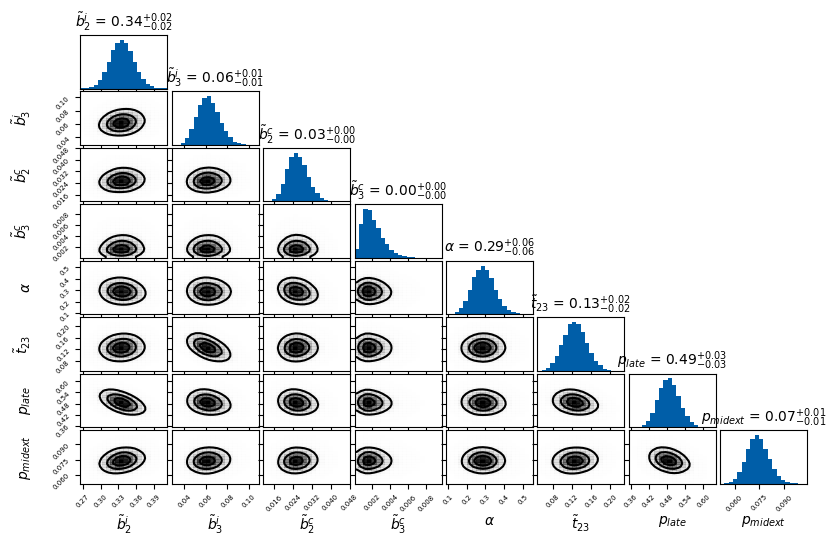

In [6]:
tau = backend.get_autocorr_time()
burnin = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))
samples = backend.get_chain(discard=burnin, flat=True, thin=thin)
print("burn-in: {0}".format(burnin))
print("thin: {0}".format(thin))
print("flat chain shape: {0}".format(samples.shape))
print(backend.get_chain().shape)


import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from cycler import cycler
import corner

# USZ colors
usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'

# colormaps
white_to_blue  = LinearSegmentedColormap.from_list("white_to_blue", 
                                                   ["#ffffff", usz_blue], 
                                                   N=256)
white_to_green = LinearSegmentedColormap.from_list("white_to_green", 
                                                   ["#ffffff", usz_green], 
                                                   N=256)
green_to_red   = LinearSegmentedColormap.from_list("green_to_red", 
                                                   [usz_green, usz_red], 
                                                   N=256)

h = usz_gray.lstrip('#')
gray_rgba = tuple(int(h[i:i+2], 16) / 255. for i in (0, 2, 4)) + (1.0,)
tmp = LinearSegmentedColormap.from_list("tmp", [usz_green, usz_red], N=128)
tmp = tmp(np.linspace(0., 1., 128))
tmp = np.vstack([np.array([gray_rgba]*128), tmp])
halfGray_halfGreenToRed = ListedColormap(tmp)


def set_size(width="single", unit="cm", ratio="golden"):
    if width == "single":
        width = 10
    elif width == "full":
        width = 20
    else:
        try:
            width = width
        except:
            width = 10
            
    if unit == "cm":
        width = width / 2.54
        
    if ratio == "golden":
        ratio = 1.618
    else:
        ratio = ratio
    
    try:
        height = width / ratio
    except:
        height = width / 1.618
        
    return (width, height)



labels = [r"$\tilde{b}^i_2$", r"$\tilde{b}^i_3$", r"$\tilde{b}^c_2$", r"$\tilde{b}^c_3$", r"$\alpha$", r"$\tilde{t}_{23}$", r"$p_{late}$", r"$p_{midext}$"]

fig = plt.figure(figsize=set_size(width="full", ratio='golden'))
# using the corner plot package

corner.corner(samples, labels=labels, smooth=True, fig=fig, 
              hist_kwargs={'histtype': 'stepfilled', 'color': usz_blue}, 
              **{'plot_datapoints': False, 'no_fill_contours': True, 
                 "density_cmap": white_to_blue.reversed(), 
                 "contour_kwargs": {"colors": "k"}, 
                 "levels": np.array([0.2, 0.5, 0.8])}, 
              show_titles=True, title_kwargs={"fontsize": 10},labelpad =0.25);

axes = fig.get_axes()
for ax in axes:
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=5)

## let's evaluate

In [7]:
import sys
sys.path.append('Trial-calculator')
from sparing_scripts import change_base, sample_from_flattened, risk_sampled, levels_to_spare, ci_single
samples_reduced = sample_from_flattened(samples, num_samples = 200)
model.set_modality('treatment_diagnose', spec = 1, sens = 0.81)

In [8]:
diagnose = {"ipsi": {'treatment_diagnose':{
        "II": 1,
        "III": 0,
    }},
    "contra": {'treatment_diagnose':{
        "II": 0,
        "III": 0,
    }}}
sampled_risks, risk = risk_sampled(samples = samples_reduced, model = model, t_stage = 'early', given_diagnoses= diagnose,central = None, midline_extension= False)     
spared_lnls, total_risk, ranked_combined, treated_lnls, treated_array, treated_ipsi, treated_contra, sampled_total_risks = levels_to_spare(0.10, model, risk, sampled_risks, ci = True)
print(treated_lnls)
print(total_risk*100)
print(spared_lnls)
ci_single(sampled_total_risks)*100

/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/bilateral.py:610: UserWarning: No diagnosis given for ipsilateral side.
  warnings.warn(f"No diagnosis given for {side}lateral side.")
/home/yoel/Documents/lymph_2026_evaluations/.venv/lib/python3.12/site-packages/lymph/models/bilateral.py:610: UserWarning: No diagnosis given for contralateral side.
  warnings.warn(f"No diagnosis given for {side}lateral side.")


[('ipsi III', np.float64(0.08004009642474388)), ('ipsi II', np.float64(0.9999999999999999))]
1.5048865870008523
[('contra III', np.float64(0.0016462205378670878)), ('contra II', np.float64(0.013875648961090722))]


array([1.07159649, 2.08154073])

In [9]:
model.noext.ipsi.graph.lnls

{'II': LymphNodeLevel(name='II', state=0, allowed_states=[0, 1]),
 'III': LymphNodeLevel(name='III', state=0, allowed_states=[0, 1])}

In [10]:
from sparing_scripts import change_base, analysis_treated_lnls_combinations_bilateral

def produce_combinations_list(array):
    combinations_list = []
    for entry in array:
        combination = []
        for index, cells in enumerate(entry):
            if index == 0:
                combination.append('early') if cells == 0 else combination.append('late')
            else:
                combination.append(False) if cells == 0 else combination.append(True)
        combination = tuple(combination)
        combinations_list.append(combination)
    return(combinations_list)

number_of_parameters = len(model.noext.ipsi.graph.lnls) * 2 + 2

combination_array = np.zeros((2**number_of_parameters,number_of_parameters))
for i in range(2**number_of_parameters):
    combination_array[i] = [
        int(digit) for digit in change_base(i, 2, length=number_of_parameters)
    ]

all_combinations = produce_combinations_list(combination_array)

In [13]:
treated_lnls_no_risk, treated_lnls_all, treatment_array, top3_spared, total_risks, treated_ipsi_all, treated_contra_all, sampled_risks_array, lnls_ranked, cis  = analysis_treated_lnls_combinations_bilateral(combinations = all_combinations[:2], model = model, samples = samples_reduced, threshold = 0.10)


In [17]:
import multiprocessing as mp

# Function to process a chunk of combinations
def process_combinations(chunk):
    return analysis_treated_lnls_combinations_bilateral(chunk, samples_reduced, model)

# Divide the combinations into chunks
num_cores = mp.cpu_count() - 1
chunk_size = len(all_combinations) // num_cores
chunks = [all_combinations[i:i + chunk_size] for i in range(0, len(all_combinations), chunk_size)]

# Use multiprocessing to process the chunks
with mp.Pool(num_cores) as pool:
    results = pool.map(process_combinations, chunks)

# Combine the results from all chunks
treated_lnls_no_risk, treated_lnls_all, treatment_array, top3_spared, total_risks, treated_ipsi, treated_contra, sampled_risks_array, lnls_ranked, cis = zip(*results)

# Flatten the results
treated_lnls_no_risk = [item for sublist in treated_lnls_no_risk for item in sublist]
treated_lnls_all = [item for sublist in treated_lnls_all for item in sublist]
treatment_array = np.vstack(treatment_array)
top3_spared = [item for sublist in top3_spared for item in sublist]
total_risks = np.concatenate(total_risks)
treated_ipsi = [item for sublist in treated_ipsi for item in sublist]
treated_contra = [item for sublist in treated_contra for item in sublist]
sampled_risks_array = np.vstack(sampled_risks_array)
lnls_ranked = [item for sublist in lnls_ranked for item in sublist]
cis_lower = []
cis_upper = []
for item in cis:
    cis_lower.append(item[0])
    cis_upper.append(item[1])
flat_lower = [item for sublist in cis_lower for item in sublist]
flat_upper = [item for sublist in cis_upper for item in sublist]

In [18]:
sampled_risks_early_no_ext, mean_risk_early_no_ext = risk_sampled(samples_reduced, model, 'early', midline_extension = False, given_diagnoses = None) 
sampled_risks_early_ext, mean_risk_early_ext = risk_sampled(samples_reduced, model, 'early', midline_extension = True, given_diagnoses = None)
sampled_risks_late_no_ext, mean_risk_late_no_ext = risk_sampled(samples_reduced, model, 'late', midline_extension = False, given_diagnoses = None)
sampled_risks_late_ext, mean_risk_late_ext = risk_sampled(samples_reduced, model, 'late', midline_extension = True, given_diagnoses = None)

In [19]:
#generate state list
state_list = np.array(np.meshgrid(*[[0, 1]] * 14)).T.reshape(-1, 14)
state_list = state_list[np.lexsort(np.fliplr(state_list).T)]
# Reshape the risk arrays into 1x4096 arrays
mean_risk_early_noext_flat = mean_risk_early_no_ext.reshape(-1)
mean_risk_early_ext_flat = mean_risk_early_ext.reshape(-1)
mean_risk_late_noext_flat = mean_risk_late_no_ext.reshape(-1)
mean_risk_late_ext_flat = mean_risk_late_ext.reshape(-1)
#combine them
full_risks = np.hstack([mean_risk_early_noext_flat, mean_risk_early_ext_flat, mean_risk_late_noext_flat, mean_risk_late_ext_flat])/4

In [21]:
lnls = ['II', 'III']
t_stage = []
midline_extension = []
invovlvement_ipsi = []
invovlvement_contra = []
for diagnose_type in all_combinations:
    involved_ipsi = []
    involved_contra = []
    t_stage.append(diagnose_type[0])
    midline_extension.append(diagnose_type[1])
    for lnl_looper, involved_level in enumerate(lnls):
        if diagnose_type[lnl_looper +2] == True:
            involved_ipsi.append(involved_level) 
        if diagnose_type[lnl_looper + len(model.noext.ipsi.graph.lnls) +2] == True:
            involved_contra.append(involved_level)
    invovlvement_ipsi.append(involved_ipsi)
    invovlvement_contra.append(involved_contra)

In [27]:
data_export = pd.DataFrame({'Percentage of patients': full_risks,
                                'T-stage': t_stage,
                                'Midline Extension': midline_extension,
                                'Involvement Ipsi' : invovlvement_ipsi,
                                'Involvement Contra': invovlvement_contra,
                                'Treated Ipsi':  treated_ipsi,
                                'Treated Contra': treated_contra,
                                'risk': total_risks,
                                'lower bound': flat_lower,
                                'upper bound': flat_upper,
                                'top 3 spared lnls risk': top3_spared,
                                'lnls ranked': lnls_ranked
})
# data_export.sort_values(by=['Percentage of patients'], ascending=False, inplace=True)

In [32]:
# Count unique treatment combinations and their frequencies
unique_combos, counts = np.unique(treatment_array, axis=0, return_counts=True)

# Assemble into a DataFrame for easier viewing
combo_counts = pd.DataFrame(unique_combos, columns=["ipsi II", "ipsi III", "contra II", "contra III"])
combo_counts["count"] = counts
combo_counts.sort_values("count", ascending=False, inplace=True)
combo_counts.reset_index(drop=True, inplace=True)
combo_counts

,ipsi II,ipsi III,contra II,contra III,count
0,1.0,1.0,1.0,1.0,29
1,1.0,1.0,1.0,0.0,20
2,1.0,1.0,0.0,0.0,10
3,1.0,0.0,1.0,1.0,3
4,1.0,0.0,1.0,0.0,1
5,1.0,0.0,0.0,0.0,1


In [30]:
data_export

,Percentage of patients,T-stage,Midline Extension,Involvement Ipsi,Involvement Contra,Treated Ipsi,Treated Contra,risk,lower bound,upper bound,top 3 spared lnls risk,lnls ranked
0,0.076748,early,False,[],[],[II],[],0.047017,0.037860,0.056786,"[(ipsi III, 0.03654454774664123), (contra II, ...","[(contra III, 0.001114366768811116), (contra I..."
1,0.000305,early,False,[],[III],[II],"[II, III]",0.059425,0.047327,0.073118,"[(ipsi III, 0.05942510873277482)]","[(ipsi III, 0.05942510873277482), (contra II, ..."
2,0.003637,early,False,[],[II],[II],[II],0.076979,0.065271,0.088774,"[(ipsi III, 0.05247131686478858), (contra III,...","[(contra III, 0.026447985365108603), (ipsi III..."
3,0.000453,early,False,[],"[II, III]",[II],"[II, III]",0.073816,0.059003,0.090599,"[(ipsi III, 0.07381584242710947)]","[(ipsi III, 0.07381584242710947), (ipsi II, 0...."
4,0.010352,early,False,[III],[],"[II, III]",[],0.015918,0.011431,0.021737,"[(contra II, 0.014667531819952409), (contra II...","[(contra III, 0.0017967996244937633), (contra ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.009582,late,True,[II],"[II, III]","[III, II]","[II, III]",0.000000,0.000000,0.000000,[],"[(ipsi III, 0.19914856111546084), (ipsi II, 0...."
60,0.064608,late,True,"[II, III]",[],"[II, III]",[II],0.018375,0.012677,0.026491,"[(contra III, 0.018374504859530225)]","[(contra III, 0.018374504859530225), (contra I..."
61,0.004464,late,True,"[II, III]",[III],"[II, III]","[II, III]",0.000000,0.000000,0.000000,[],"[(contra II, 0.35015896038307803), (ipsi II, 1..."
62,0.029728,late,True,"[II, III]",[II],"[II, III]",[II],0.074178,0.054248,0.093716,"[(contra III, 0.07417776617250815)]","[(contra III, 0.07417776617250815), (ipsi II, ..."
